# CHARACTERISTIC TIMES

In [1]:
from src.system_discovery import SystemDiscovery, discoverNetwork
import src.constants as cn
from src.biomodels_iterator import BiomodelsIterator
from src.timecourse import Timecourse
from src.model import Model
from src.characteristic_time_estimator import CharacteristicTimeEstimator
from src.simulator import Simulator

import collections
import os
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import sbmlnetwork as sb # type: ignore
import tellurium as te  # type: ignore
from typing import Optional

# Basic Plots

In [2]:
estimator = CharacteristicTimeEstimator(Model.makeBiomodel(model_num=45))

In [3]:
#estimator.detect_steadystate()

In [4]:
estimator.detect_cv_maximized()

14.628637493591308

In [5]:
estimator = CharacteristicTimeEstimator(Model.makeBiomodel(model_num=45))
endtime_steady = estimator.detect_steadystate()
print(endtime_steady)

-1


In [10]:
estimator = CharacteristicTimeEstimator(Model.makeBiomodel(model_num=45))
endtime_cvmax = estimator.detect_cv_maximized()
endtime_steady = estimator.detect_steadystate()
simulator = Simulator(Model.makeBiomodel(model_num=45), start_time=0, end_time=endtime_cvmax, num_point=1000)
result_df = simulator.simulate().timecourse_df

In [11]:
print(endtime_steady)

-1


<Axes: xlabel='time'>

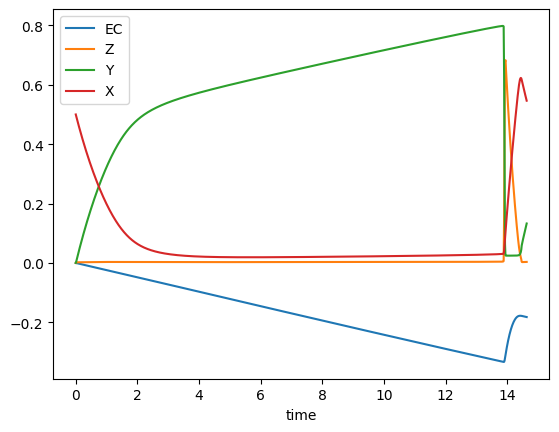

In [7]:
result_df.plot()

[None,

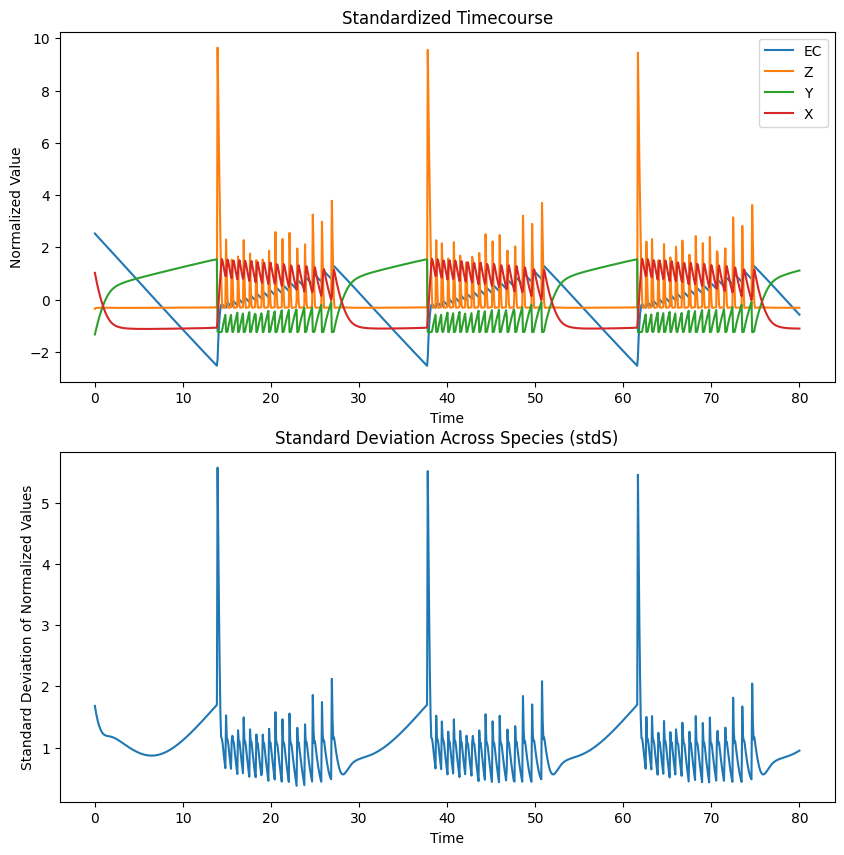

In [8]:
_, (ax_mid, ax_bot) = plt.subplots(2,1, figsize=(10, 10))
estimator.plotStdNrml(end_time=80, ax_mid=ax_mid, ax_bot=ax_bot)

# Signal timeout

In [9]:
import signal
import time

def func(sleep_sec):
    time.sleep(sleep_sec)
    

class TimeoutError(Exception):
    pass

def handler(signum, frame):
    raise TimeoutError("Function timed out")

def run_with_timeout(func, pos_args=(), kwargs={}, timeout=1):
    old_handler = signal.signal(signal.SIGALRM, handler)
    signal.alarm(timeout)
    try:
        result = func(pos_args)
        print("No timeout")
    except TimeoutError:
        print("Timed out!")
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old_handler)

run_with_timeout(func, 5)

Timed out!
